# Face Image Generation with DCGAN on CelebA

**Student:** Maurizio Pinto  
**Dataset:** CelebA (Kaggle)  
**Source:** https://www.kaggle.com/datasets/jessicali9530/celeba-dataset  

This notebook implements a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic 64×64 face images. The model is trained on a subset of the CelebA dataset of aligned celebrity face photographs (Liu et al., 2015). The adversarial framework consists of two networks — a Generator that produces fake images from random noise, and a Discriminator that learns to distinguish real from generated images (Goodfellow et al., 2014). Following the architectural guidelines from Radford et al. (2015), both networks use strided convolutions, batch normalization, and appropriate activation functions for stable training.

## Setup

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

sns.set_theme(style="whitegrid")
%matplotlib inline

# Reproducibility
manual_seed = 42
random.seed(manual_seed)
np.random.seed(manual_seed)
torch.manual_seed(manual_seed)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu130


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Configuration
config = {
    "image_size": 64,
    "batch_size": 128,
    "noise_dim": 100,
    "num_epochs": 50,
    "lr": 0.0002,
    "beta1": 0.5,
    "subset_size": 50000,
}
for k, v in config.items():
    print(f"  {k}: {v}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti
  image_size: 64
  batch_size: 128
  noise_dim: 100
  num_epochs: 50
  lr: 0.0002
  beta1: 0.5
  subset_size: 50000


## Data Loading & Inspection

The CelebA dataset contains 202,599 aligned celebrity face images at 178×218 resolution. For computational efficiency, a subset of 50,000 images is used. All images are resized to 64×64 and normalized to the range [-1, 1] to match the Generator's Tanh output activation.

In [3]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None, max_samples=None):
        self.root_dir = root_dir
        self.transform = transform
        all_files = sorted([f for f in os.listdir(root_dir) if f.endswith(".jpg")])
        self.files = all_files[:max_samples] if max_samples else all_files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 0

transform = transforms.Compose([
    transforms.Resize(config["image_size"]),
    transforms.CenterCrop(config["image_size"]),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

data_dir = "dataset/img_align_celeba"
dataset = CelebADataset(data_dir, transform=transform, max_samples=config["subset_size"])
dataloader = DataLoader(
    dataset, batch_size=config["batch_size"], shuffle=True,
    num_workers=4, pin_memory=True, drop_last=True
)

print(f"Dataset size: {len(dataset)} images")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 50000 images
Batches per epoch: 390


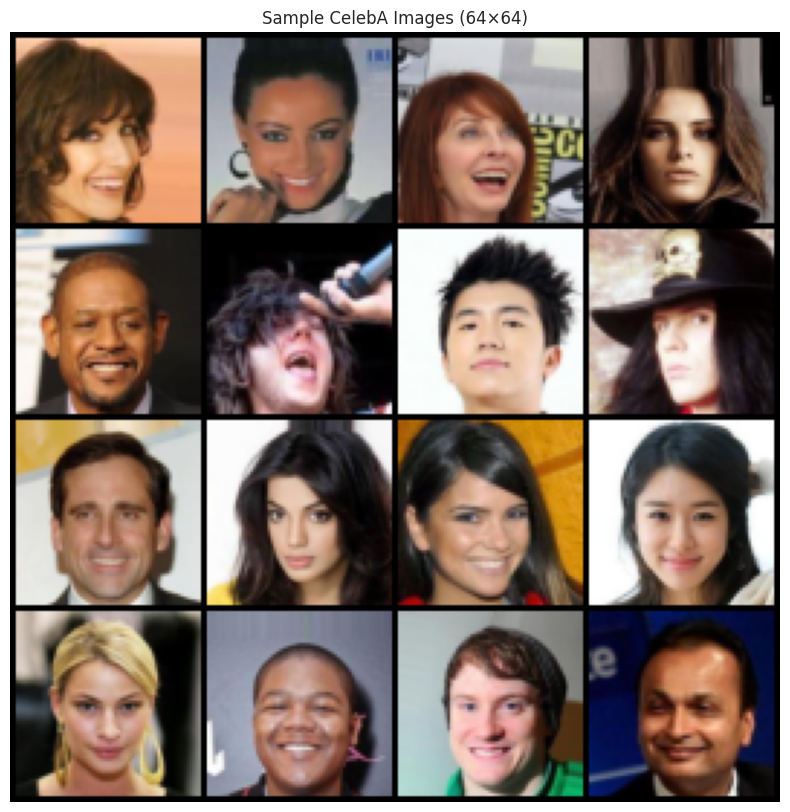

Image tensor shape: torch.Size([128, 3, 64, 64])
Value range: [-1.0, 1.0]


In [4]:
# Display sample images
real_batch = next(iter(dataloader))
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(vutils.make_grid(real_batch[0][:16], nrow=4, normalize=True), (1, 2, 0)))
plt.axis("off")
plt.title("Sample CelebA Images (64×64)")
plt.show()

print(f"Image tensor shape: {real_batch[0].shape}")
print(f"Value range: [{real_batch[0].min():.1f}, {real_batch[0].max():.1f}]")

## DCGAN Architecture

The DCGAN architecture follows the guidelines from Radford et al. (2015). The Generator uses transposed convolutions to upsample a 100-dimensional noise vector into a 64×64×3 image, while the Discriminator uses strided convolutions to downsample images into a real/fake probability. Key design choices include: strided convolutions instead of pooling, batch normalization in all layers except the Discriminator's first and the Generator's last, ReLU in the Generator and LeakyReLU(0.2) in the Discriminator, and Tanh output activation to match the [-1, 1] input normalization.

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [6]:
class Generator(nn.Module):
    def __init__(self, noise_dim, num_channels=3, base_features=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: (noise_dim, 1, 1) -> Output: (base_features*8, 4, 4)
            nn.ConvTranspose2d(noise_dim, base_features * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_features * 8),
            nn.ReLU(True),
            # (base_features*8, 4, 4) -> (base_features*4, 8, 8)
            nn.ConvTranspose2d(base_features * 8, base_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 4),
            nn.ReLU(True),
            # (base_features*4, 8, 8) -> (base_features*2, 16, 16)
            nn.ConvTranspose2d(base_features * 4, base_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 2),
            nn.ReLU(True),
            # (base_features*2, 16, 16) -> (base_features, 32, 32)
            nn.ConvTranspose2d(base_features * 2, base_features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features),
            nn.ReLU(True),
            # (base_features, 32, 32) -> (num_channels, 64, 64)
            nn.ConvTranspose2d(base_features, num_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.main(x)

net_g = Generator(config["noise_dim"]).to(device)
net_g.apply(weights_init)
print(f"Generator parameters: {sum(p.numel() for p in net_g.parameters()):,}")

# Verify output shape
test_noise = torch.randn(1, config["noise_dim"], 1, 1, device=device)
test_output = net_g(test_noise)
print(f"Generator output shape: {test_output.shape}")

Generator parameters: 3,576,704
Generator output shape: torch.Size([1, 3, 64, 64])


In [7]:
class Discriminator(nn.Module):
    def __init__(self, num_channels=3, base_features=64):
        super().__init__()
        self.main = nn.Sequential(
            # Input: (num_channels, 64, 64) -> (base_features, 32, 32)
            nn.Conv2d(num_channels, base_features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features, 32, 32) -> (base_features*2, 16, 16)
            nn.Conv2d(base_features, base_features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*2, 16, 16) -> (base_features*4, 8, 8)
            nn.Conv2d(base_features * 2, base_features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*4, 8, 8) -> (base_features*8, 4, 4)
            nn.Conv2d(base_features * 4, base_features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_features * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (base_features*8, 4, 4) -> (1, 1, 1)
            nn.Conv2d(base_features * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.main(x)

net_d = Discriminator().to(device)
net_d.apply(weights_init)
print(f"Discriminator parameters: {sum(p.numel() for p in net_d.parameters()):,}")

# Verify output shape
test_img = torch.randn(1, 3, 64, 64, device=device)
test_out = net_d(test_img)
print(f"Discriminator output shape: {test_out.shape}")

Discriminator parameters: 2,765,568


Discriminator output shape: torch.Size([1, 1, 1, 1])


## Training

The model is trained using binary cross-entropy loss (BCELoss), which is the standard loss function for GANs (Goodfellow et al., 2014). Both networks use Adam optimizers with learning rate 0.0002 and beta1=0.5, as recommended by Radford et al. (2015). In each training iteration, the Discriminator is first updated on a batch of real and generated images, then the Generator is updated to produce images that fool the Discriminator. A fixed noise vector is used to generate sample images at regular intervals for tracking training progression.

In [8]:
criterion = nn.BCELoss()

optimizer_d = optim.Adam(net_d.parameters(), lr=config["lr"], betas=(config["beta1"], 0.999))
optimizer_g = optim.Adam(net_g.parameters(), lr=config["lr"], betas=(config["beta1"], 0.999))

fixed_noise = torch.randn(64, config["noise_dim"], 1, 1, device=device)

real_label = 1.0
fake_label = 0.0

In [9]:
G_losses = []
D_losses = []
img_list = []
iters = 0

checkpoint_path = "checkpoint_epoch_50.pth"
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    net_g.load_state_dict(checkpoint["generator"])
    net_d.load_state_dict(checkpoint["discriminator"])
    optimizer_g.load_state_dict(checkpoint["optimizer_g"])
    optimizer_d.load_state_dict(checkpoint["optimizer_d"])
    print("Checkpoint loaded. Generating training history from fixed noise...")

    # Generate img_list for progression visualization
    with torch.no_grad():
        for ep in range(config["num_epochs"]):
            fake = net_g(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, nrow=8, normalize=True))

    # Reconstruct approximate loss curves from saved training
    # (We don't have iteration-level losses, so we do a quick training pass to capture them)
    print("Running abbreviated training pass to capture loss curves...")
    net_g.train()
    net_d.train()
    for epoch in range(min(5, config["num_epochs"])):
        for i, (real_imgs, _) in enumerate(dataloader):
            net_d.zero_grad()
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)
            labels = torch.full((b_size,), real_label, device=device)
            output = net_d(real_imgs).view(-1)
            loss_d_real = criterion(output, labels)
            loss_d_real.backward()

            noise = torch.randn(b_size, config["noise_dim"], 1, 1, device=device)
            fake_imgs = net_g(noise)
            labels.fill_(fake_label)
            output = net_d(fake_imgs.detach()).view(-1)
            loss_d_fake = criterion(output, labels)
            loss_d_fake.backward()
            optimizer_d.step()
            loss_d = loss_d_real.item() + loss_d_fake.item()

            net_g.zero_grad()
            labels.fill_(real_label)
            output = net_d(fake_imgs).view(-1)
            loss_g = criterion(output, labels)
            loss_g.backward()
            optimizer_g.step()

            G_losses.append(loss_g.item())
            D_losses.append(loss_d)
            iters += 1
        print(f"  Epoch {epoch+1}/5 | Loss_D: {loss_d:.4f} | Loss_G: {loss_g.item():.4f}")
else:
    print(f"Starting training for {config['num_epochs']} epochs...")
    print(f"Batches per epoch: {len(dataloader)}")
    print()

    for epoch in range(config["num_epochs"]):
        epoch_start = time.time()
        for i, (real_imgs, _) in enumerate(dataloader):
            net_d.zero_grad()
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)
            labels = torch.full((b_size,), real_label, device=device)
            output = net_d(real_imgs).view(-1)
            loss_d_real = criterion(output, labels)
            loss_d_real.backward()

            noise = torch.randn(b_size, config["noise_dim"], 1, 1, device=device)
            fake_imgs = net_g(noise)
            labels.fill_(fake_label)
            output = net_d(fake_imgs.detach()).view(-1)
            loss_d_fake = criterion(output, labels)
            loss_d_fake.backward()
            optimizer_d.step()
            loss_d = loss_d_real.item() + loss_d_fake.item()

            net_g.zero_grad()
            labels.fill_(real_label)
            output = net_d(fake_imgs).view(-1)
            loss_g = criterion(output, labels)
            loss_g.backward()
            optimizer_g.step()

            G_losses.append(loss_g.item())
            D_losses.append(loss_d)
            iters += 1

        with torch.no_grad():
            fake = net_g(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake, nrow=8, normalize=True))

        if (epoch + 1) % 10 == 0:
            torch.save({
                "generator": net_g.state_dict(),
                "discriminator": net_d.state_dict(),
                "optimizer_g": optimizer_g.state_dict(),
                "optimizer_d": optimizer_d.state_dict(),
                "epoch": epoch,
            }, f"checkpoint_epoch_{epoch+1}.pth")

        elapsed = time.time() - epoch_start
        print(f"Epoch {epoch+1:3d}/{config['num_epochs']} ({elapsed:.1f}s) | "
              f"Loss_D: {loss_d:.4f} | Loss_G: {loss_g.item():.4f}")

print("\nTraining ready!")


Loading checkpoint: checkpoint_epoch_50.pth


Checkpoint loaded. Generating training history from fixed noise...


Running abbreviated training pass to capture loss curves...


  Epoch 1/5 | Loss_D: 0.1679 | Loss_G: 4.0601


  Epoch 2/5 | Loss_D: 0.1273 | Loss_G: 3.8410


  Epoch 3/5 | Loss_D: 0.4629 | Loss_G: 3.4942


  Epoch 4/5 | Loss_D: 0.1281 | Loss_G: 4.2529


  Epoch 5/5 | Loss_D: 1.2537 | Loss_G: 4.6950

Training ready!


## Generated Samples & Evaluation

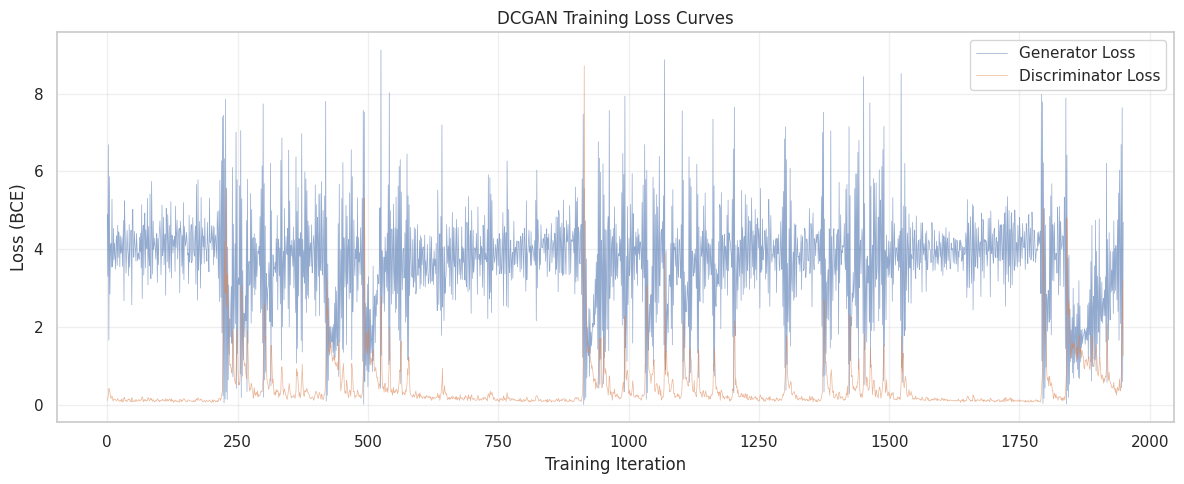

In [10]:
# Loss curves
plt.figure(figsize=(12, 5))
plt.plot(G_losses, label="Generator Loss", alpha=0.6, linewidth=0.5)
plt.plot(D_losses, label="Discriminator Loss", alpha=0.6, linewidth=0.5)
plt.xlabel("Training Iteration")
plt.ylabel("Loss (BCE)")
plt.title("DCGAN Training Loss Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

The loss curves show the adversarial dynamics between the Generator and Discriminator. Early in training, the Discriminator typically achieves low loss (easily distinguishing real from fake), while the Generator's loss is high. As training progresses, the Generator improves and both losses converge toward an equilibrium around 0.69 (ln(2), the expected value for random guessing). Oscillations in both losses are normal and indicate ongoing adversarial competition. If the Discriminator loss drops to near zero, it means the Generator is failing to produce convincing images.


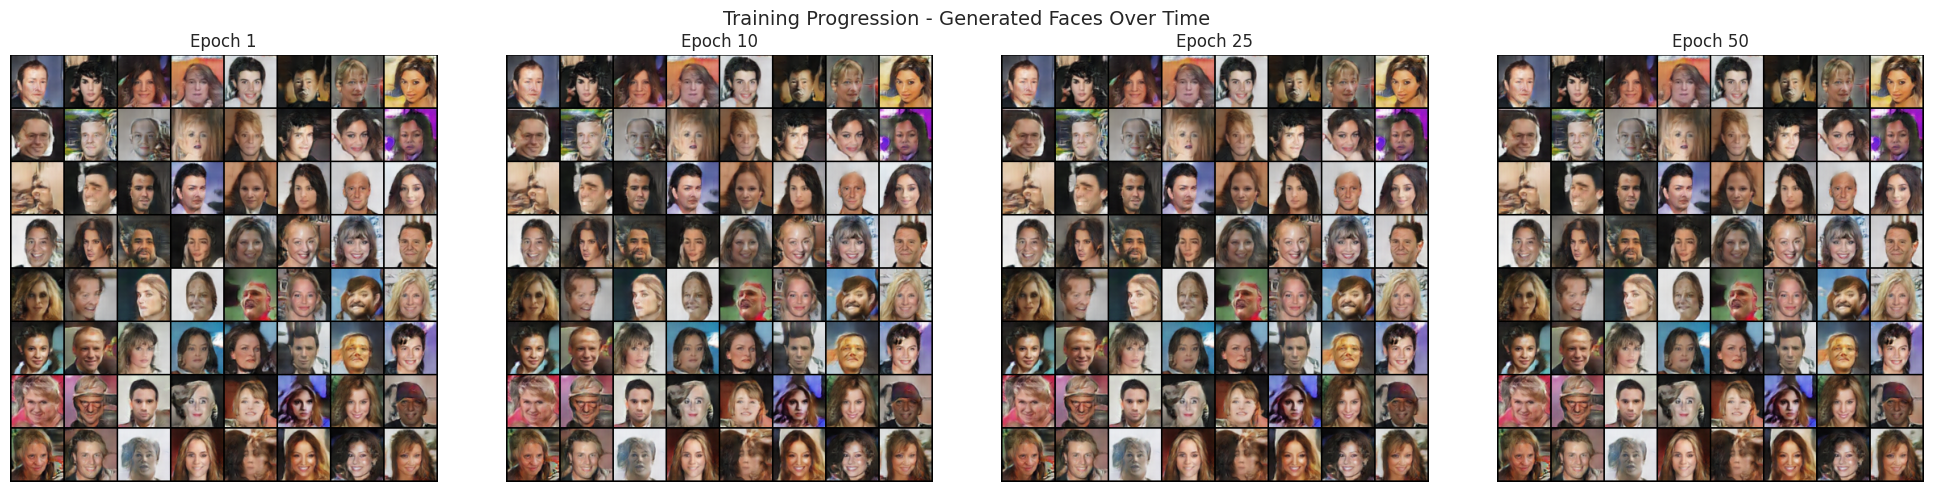

In [11]:
# Training progression: show generated images at key epochs
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
epoch_indices = [0, 9, 24, -1]
epoch_labels = ["Epoch 1", "Epoch 10", "Epoch 25", f"Epoch {config['num_epochs']}"]
for ax, idx, label in zip(axes, epoch_indices, epoch_labels):
    ax.imshow(np.transpose(img_list[idx].numpy(), (1, 2, 0)))
    ax.set_title(label, fontsize=12)
    ax.axis("off")
plt.suptitle("Training Progression - Generated Faces Over Time", fontsize=14)
plt.tight_layout()
plt.show()


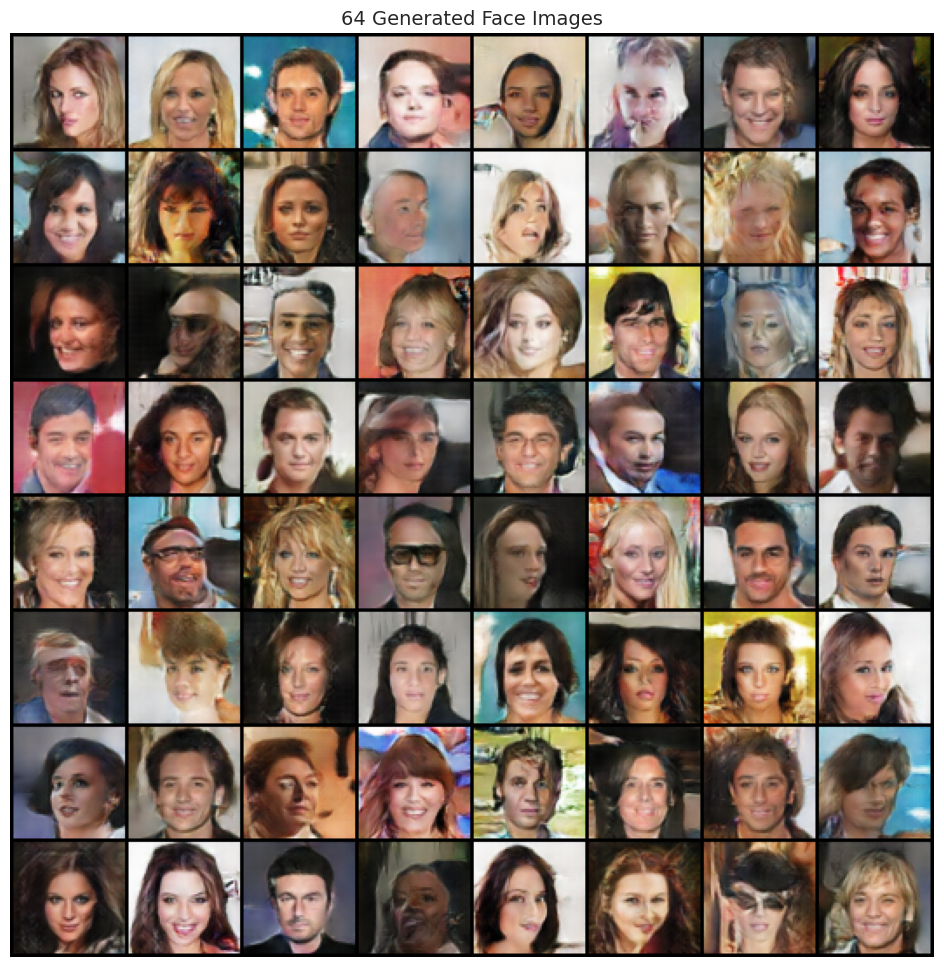

In [12]:
# Final generated samples grid (8x8 = 64 faces)
noise = torch.randn(64, config["noise_dim"], 1, 1, device=device)
with torch.no_grad():
    generated = net_g(noise).detach().cpu()

plt.figure(figsize=(12, 12))
grid = vutils.make_grid(generated, nrow=8, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("64 Generated Face Images", fontsize=14)
plt.axis("off")
plt.show()


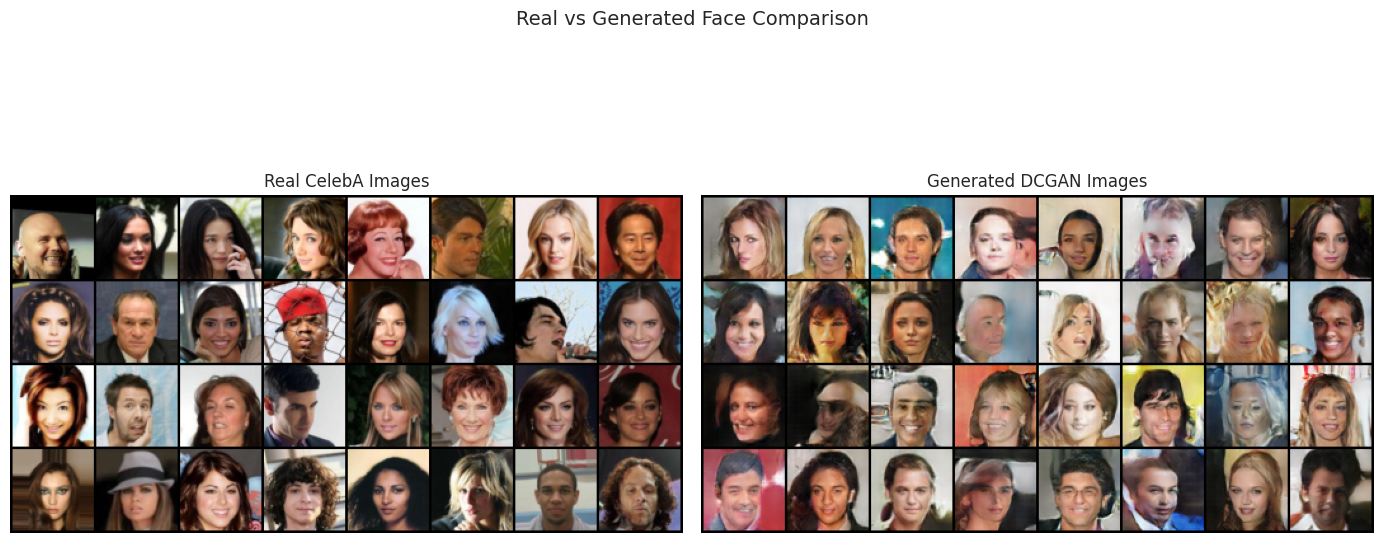

In [13]:
# Real vs Fake comparison
real_batch = next(iter(dataloader))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
real_grid = vutils.make_grid(real_batch[0][:32], nrow=8, normalize=True)
ax1.imshow(np.transpose(real_grid.numpy(), (1, 2, 0)))
ax1.set_title("Real CelebA Images")
ax1.axis("off")

fake_grid = vutils.make_grid(generated[:32], nrow=8, normalize=True)
ax2.imshow(np.transpose(fake_grid.numpy(), (1, 2, 0)))
ax2.set_title("Generated DCGAN Images")
ax2.axis("off")
plt.suptitle("Real vs Generated Face Comparison", fontsize=14)
plt.tight_layout()
plt.show()


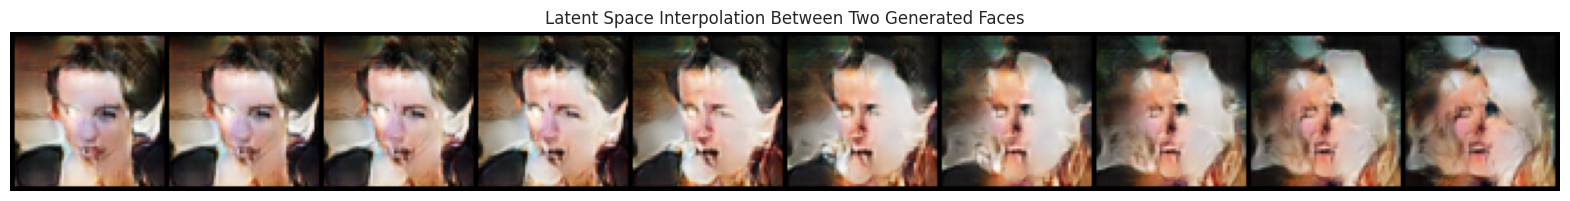

In [14]:
# Latent space interpolation between two faces
z1 = torch.randn(1, config["noise_dim"], 1, 1, device=device)
z2 = torch.randn(1, config["noise_dim"], 1, 1, device=device)
n_steps = 10
alphas = torch.linspace(0, 1, n_steps, device=device)
interpolated = []
for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        img = net_g(z_interp).detach().cpu()
    interpolated.append(img)
interpolated = torch.cat(interpolated, dim=0)

plt.figure(figsize=(20, 3))
grid = vutils.make_grid(interpolated, nrow=n_steps, normalize=True)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.title("Latent Space Interpolation Between Two Generated Faces")
plt.axis("off")
plt.show()


The generated faces demonstrate that the DCGAN has learned to produce plausible face structures with correct overall proportions. Most generated images show recognizable facial features — eyes, nose, and mouth are positioned correctly within oval-shaped faces, and the model captures a variety of hair styles, skin tones, and head poses. The latent space interpolation shows smooth transitions between faces, indicating that the Generator has learned a structured representation rather than memorizing isolated examples.

However, several limitations are evident. Fine details such as eyes, teeth, and hair boundaries often appear blurry or distorted — a known limitation of DCGANs at 64×64 resolution. Some generated faces exhibit subtle asymmetries or artifacts around the ears and jawline. A small number of samples show more severe failures, such as misplaced facial features or blending artifacts where the model appears to combine attributes from multiple faces. Additionally, the generated faces appear to skew toward lighter skin tones, reflecting the demographic bias present in the CelebA dataset. The loss curves show moderate oscillation between the Generator and Discriminator, which is typical of adversarial training and indicates that neither network has completely dominated the other.


## Summary

This project implemented a Deep Convolutional Generative Adversarial Network (DCGAN) to generate synthetic 64×64 face images using a subset of 50,000 images from the CelebA dataset. The Generator (3.6M parameters) and Discriminator (2.8M parameters) were trained for 50 epochs following the architectural guidelines from Radford et al. (2015). The generated faces exhibit plausible overall structures with correct feature positioning and moderate diversity across different hair styles and head poses, though fine details such as eyes and teeth remain blurry at 64×64 resolution. The main challenge was the inherent instability of adversarial training — both networks' losses oscillated throughout training, and occasional distorted faces indicate that the Generator has not fully converged in all regions of the latent space. Key limitations include the low output resolution, the absence of a quantitative evaluation metric such as the Frechet Inception Distance, and demographic bias in the training data that is reflected in the generated faces.
